In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<a href="https://colab.research.google.com/github/Ravindran-M/img-classify-CNN/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
IMG_SIZE=(256,256,3)
premodel=keras.applications.EfficientNetV2L(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=IMG_SIZE,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    include_preprocessing=True,
)

473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
premodel.trainable=False


premodel.summary()


Model: "efficientnetv2-l"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 256, 256, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 128, 128, 32)   │            864 │ rescaling[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 128, 128, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 128, 128, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 128, 128, 32)   │          9,216 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 128, 128, 32)   │            128 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 128, 128, 32)   │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_add (Add)         │ (None, 128, 128, 32)   │              0 │ block1a_project_activ… │
│                           │                        │                │ stem_activation[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_conv      │ (None, 128, 128, 32)   │          9,216 │ block1a_add[0][0]      │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_bn        │ (None, 128, 128, 32)   │            128 │ block1b_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_activati… │ (None, 128, 128, 32)   │              0 │ block1b_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_drop (Dropout)    │ (None, 128, 128, 32)   │              0 │ block1b_project_activ… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_add (Add)         │ (None, 128, 128, 32)   │              0 │ block1b_drop[0][0],    │
│                           │                        │                │ block1a_add[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1c_project_conv 

 Total params: 117,746,848 (449.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 117,746,848 (449.17 MB)

In [5]:
model= keras.Sequential()
model.add(premodel)
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(1000,activation='relu'))
model.add(keras.layers.Dense(4,activation='softmax'))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1000)                │      81,921,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           4,004 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 199,671,852 (761.69 MB)

 Trainable params: 81,925,004 (312.52 MB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [6]:
(train_ds),(test_ds)= keras.utils.image_dataset_from_directory(
    directory='drive/MyDrive/BrainMRIimage',
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='both',
    seed=42,
    batch_size=32,
    shuffle=True,

)



Found 3096 files belonging to 4 classes.
Using 2477 files for training.
Using 619 files for validation.


In [7]:
class_names = train_ds.class_names
print(class_names)

['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


In [8]:
print(len(train_ds))
print(len(test_ds))

78
20


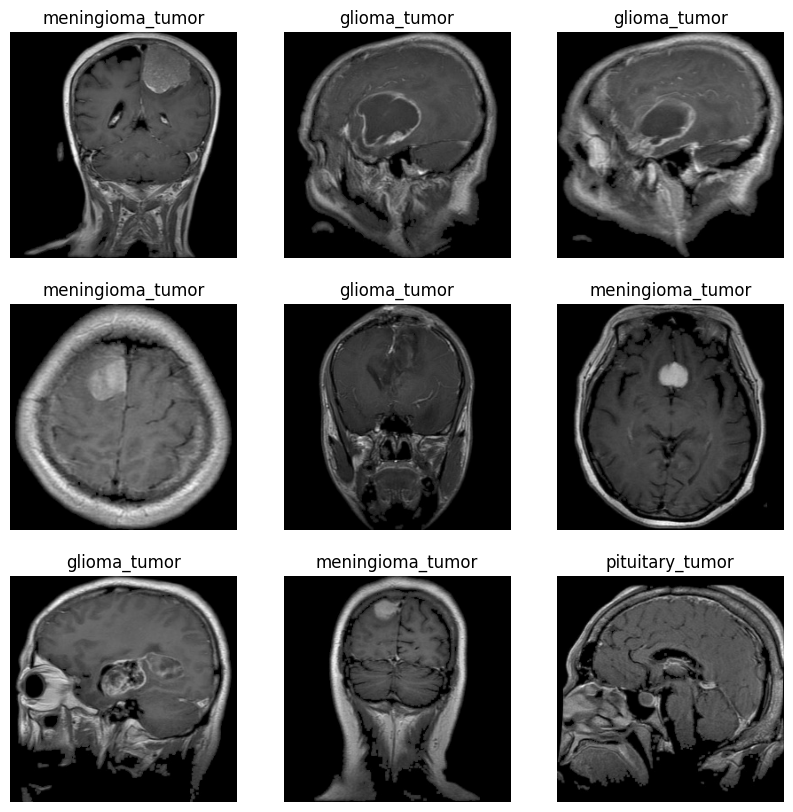

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy,
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1000)                │      81,921,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           4,004 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 199,671,852 (761.69 MB)

 Trainable params: 81,925,004 (312.52 MB)

 Non-trainable params: 117,746,848 (449.17 MB)

In [11]:
history = model.fit(train_ds, epochs=20, validation_data=(test_ds))

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 576s 6s/step - accuracy: 0.4949 - loss: 29.3350 - val_accuracy: 0.7609 - val_loss: 0.5855
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 70s 519ms/step - accuracy: 0.8155 - loss: 0.4961 - val_accuracy: 0.8320 - val_loss: 0.4557
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 526ms/step - accuracy: 0.8611 - loss: 0.3626 - val_accuracy: 0.8627 - val_loss: 0.3774
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 78s 479ms/step - accuracy: 0.8898 - loss: 0.2794 - val_accuracy: 0.8691 - val_loss: 0.3658
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 487ms/step - accuracy: 0.9372 - loss: 0.1734 - val_accuracy: 0.8643 - val_loss: 0.3884
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 40s 479ms/step - accuracy: 0.9410 - loss: 0.1758 - val_accuracy: 0.8724 - val_loss: 0.3177
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 44s 522ms/step - accuracy: 0.9220 - loss: 0.2428 - val_accuracy: 0.8595 - val_loss: 0.3824
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 520ms/step - accuracy: 0.9420 - loss: 0.1643 - val_accur

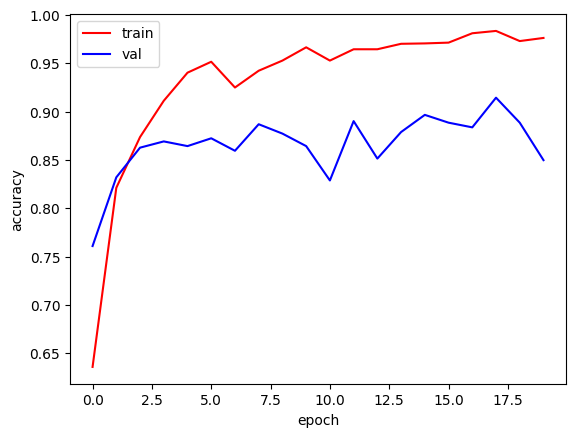

In [12]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

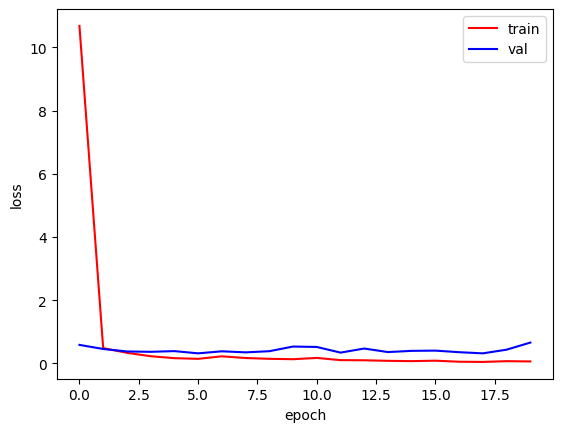

In [13]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [14]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)  # Get predicted labels for all samples
true_labels = []

# Extract true labels from the test dataset
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

accuracy=accuracy_score(true_labels, predicted_labels)
print(f'Accuracy: {accuracy}')
precision = precision_score(true_labels, predicted_labels, average='weighted')
print(f'Precision: {precision}')
recall= recall_score(true_labels, predicted_labels, average='weighted')
print(f'Recall: {recall}')
f1_score= f1_score(true_labels, predicted_labels, average='weighted')
print(f'F1 Score: {f1_score}')
confusion_matrix= confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{confusion_matrix}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step
Accuracy: 0.8497576736672051
Precision: 0.8796720858845429
Recall: 0.8497576736672051
F1 Score: 0.8515040192268771
Confusion Matrix:
[[122  45   4   2]
 [  4 186   3   2]
 [  0   4  69   0]
 [  0  29   0 149]]


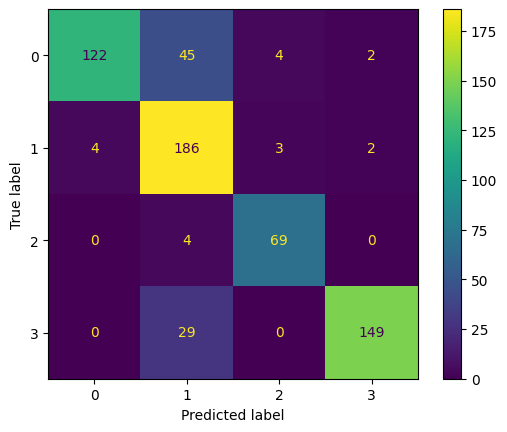

In [15]:
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [16]:
print(predicted_labels)

[0 1 1 1 0 1 1 0 3 3 2 3 2 1 0 0 1 1 3 3 3 1 1 0 3 0 0 3 1 3 3 2 1 1 1 0 1
 0 3 2 1 1 3 1 2 1 0 1 2 3 1 1 1 0 0 0 0 3 1 3 3 1 3 2 1 1 1 3 0 0 3 0 0 3
 3 1 0 1 0 3 1 1 1 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 1 1 1 2 3 2 1 0 0 1 1 0 0
 3 0 1 3 0 2 1 3 1 0 3 0 1 1 1 3 3 3 1 3 3 1 0 2 0 0 3 1 1 0 1 2 3 3 1 1 1
 2 0 3 1 1 0 3 3 1 3 1 3 1 1 2 1 1 3 1 1 0 3 0 1 0 1 0 0 0 1 1 1 1 3 1 1 2
 1 3 1 0 3 1 1 1 0 0 2 3 3 1 0 0 1 3 1 0 0 1 1 0 1 3 1 3 1 0 1 1 3 3 3 2 1
 0 0 1 2 2 1 1 1 3 2 0 3 0 3 3 0 1 0 3 0 3 1 2 2 0 1 3 0 0 1 3 0 1 0 3 3 1
 0 1 1 2 2 0 1 2 1 1 1 1 1 0 1 0 1 3 1 1 3 3 3 1 3 2 1 0 3 0 0 3 3 1 1 3 0
 2 2 1 3 3 3 2 1 0 0 1 3 3 1 1 1 1 1 1 1 1 1 3 1 0 1 1 3 1 2 2 2 0 3 3 1 1
 1 1 1 0 0 1 2 2 0 1 3 1 2 3 0 3 1 2 0 3 0 3 3 1 0 1 1 2 2 3 1 1 3 3 3 2 0
 2 1 1 1 2 1 3 1 1 1 1 1 0 1 0 1 1 2 1 3 1 2 1 0 1 0 3 1 1 1 3 1 3 1 1 3 1
 1 1 3 1 0 2 0 1 1 3 3 1 2 1 3 1 2 1 1 1 1 0 1 1 0 1 1 1 3 3 1 1 1 2 2 2 1
 1 1 3 3 1 1 0 3 1 3 1 1 2 1 1 3 1 0 1 3 3 1 1 2 1 1 0 3 0 1 3 2 1 0 1 3 0
 0 1 3 1 3 1 3 1 1 3 2 1 

In [17]:
print(true_labels)

[0 1 1 1 0 1 1 0 3 3 2 3 2 1 0 0 3 1 3 3 3 0 0 0 3 0 0 3 1 3 3 2 1 1 0 0 1
 0 3 2 1 1 3 3 2 1 1 1 2 3 1 1 1 1 0 0 0 3 1 3 3 1 1 2 1 1 1 3 0 0 3 0 0 3
 3 0 0 3 0 3 2 3 0 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 1 1 1 2 3 2 0 0 0 1 1 0 0
 0 0 1 3 0 2 0 3 1 0 3 0 1 1 1 3 3 3 1 3 3 1 0 2 0 0 3 1 0 0 1 1 3 3 1 3 1
 2 0 3 1 1 0 3 3 3 3 1 3 1 1 2 1 1 3 1 1 0 3 0 1 0 1 0 0 0 1 1 0 0 3 1 1 2
 1 3 0 0 3 2 1 1 0 0 0 3 3 3 0 0 0 0 1 0 0 1 1 0 1 3 3 3 1 0 0 1 3 3 3 2 1
 0 0 0 2 2 0 1 1 3 2 1 3 0 3 3 0 0 0 3 0 3 1 2 2 0 1 3 0 0 1 3 0 1 0 3 3 1
 0 3 1 2 2 0 3 2 1 3 0 1 1 0 0 0 0 3 3 1 3 3 3 1 3 2 1 0 3 0 0 3 3 1 1 3 0
 0 2 1 3 3 3 2 1 1 0 1 3 3 0 3 1 1 1 3 1 3 1 3 1 0 1 1 3 0 2 2 2 0 3 3 0 0
 1 1 1 0 0 1 2 2 0 1 3 1 2 3 0 3 1 2 0 3 0 3 3 1 0 1 1 2 2 3 1 0 3 3 3 2 0
 2 1 0 1 2 1 3 3 3 0 1 3 0 1 0 2 3 2 0 3 0 0 0 0 0 0 3 1 1 1 3 1 3 1 1 3 1
 0 1 3 0 0 2 0 1 1 3 3 1 2 1 3 1 2 0 0 1 0 0 1 1 0 1 1 1 3 3 1 1 1 2 1 2 1
 1 1 3 3 1 1 0 3 1 3 3 3 2 1 1 3 1 0 1 3 3 3 1 2 0 1 0 3 0 1 3 2 1 0 0 3 0
 0 3 3 1 3 1 3 1 1 3 2 3 

In [18]:
print(test_ds.class_names[0])

glioma_tumor


In [19]:
premodel.trainable=True
model.compile(optimizer=keras.optimizers.Adam(1e-4),loss=keras.losses.SparseCategoricalCrossentropy,metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 8, 8, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 81920)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1000)                │      81,921,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           4,004 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 199,671,852 (761.69 MB)

 Trainable params: 199,159,276 (759.73 MB)

 Non-trainable params: 512,576 (1.96 MB)

In [21]:
history1=model.fit(train_ds,epochs=20,validation_data=test_ds)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 691s 5s/step - accuracy: 0.7338 - loss: 1.6028 - val_accuracy: 0.8982 - val_loss: 0.2730
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9525 - loss: 0.1506 - val_accuracy: 0.9289 - val_loss: 0.2184
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9701 - loss: 0.0730 - val_accuracy: 0.9305 - val_loss: 0.2276
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9825 - loss: 0.0491 - val_accuracy: 0.9289 - val_loss: 0.2282
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9912 - loss: 0.0341 - val_accuracy: 0.9386 - val_loss: 0.2317
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9906 - loss: 0.0246 - val_accuracy: 0.9370 - val_loss: 0.2331
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9901 - loss: 0.0300 - val_accuracy: 0.9435 - val_loss: 0.2199
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9947 - loss: 0.0230 - val_accuracy: 0.9451 - v

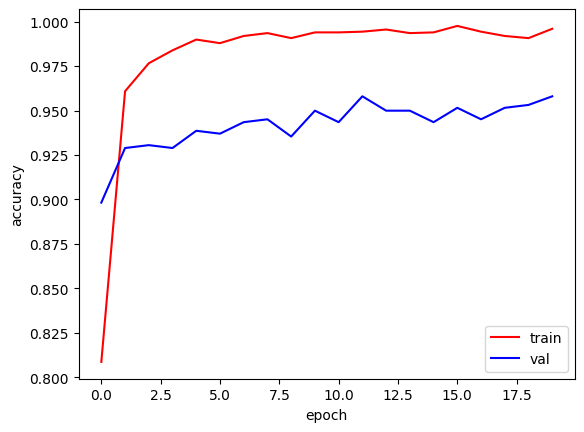

In [22]:
plt.plot(history1.history['accuracy'],color='red',label='train')
plt.plot(history1.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

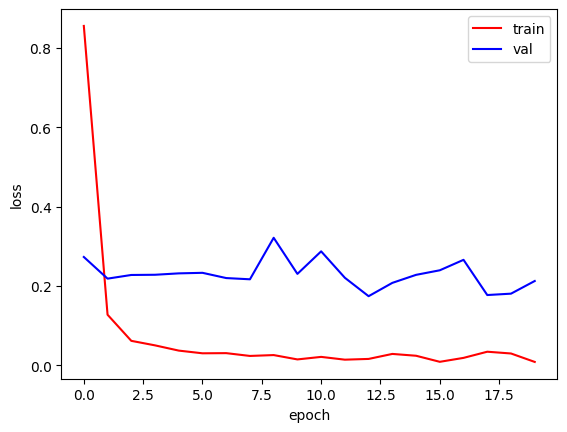

In [23]:
plt.plot(history1.history['loss'],color='red',label='train')
plt.plot(history1.history['val_loss'],color='blue',label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)  # Get predicted labels for all samples
true_labels = []

# Extract true labels from the test dataset
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

accuracy=accuracy_score(true_labels, predicted_labels)
print(f'Accuracy: {accuracy}')
precision = precision_score(true_labels, predicted_labels, average='weighted')
print(f'Precision: {precision}')
recall= recall_score(true_labels, predicted_labels, average='weighted')
print(f'Recall: {recall}')
f1_score= f1_score(true_labels, predicted_labels, average='weighted')
print(f'F1 Score: {f1_score}')
confusion_matrix= confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{confusion_matrix}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step
Accuracy: 0.9579967689822294
Precision: 0.957956362695081
Recall: 0.9579967689822294
F1 Score: 0.9579331000909193
Confusion Matrix:
[[164   7   2   0]
 [  7 184   0   4]
 [  1   2  69   1]
 [  1   1   0 176]]


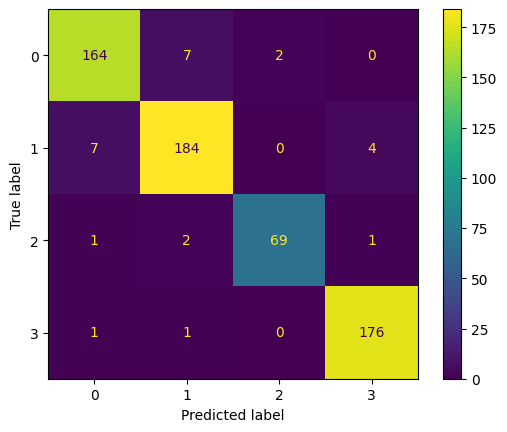

In [26]:
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()